# NLP Practical Final Test
**Name:** Kato Joseph Bwanika  
**Reg:** 2023-B291-11709  
**Task:** Sentiment Analysis and Topic Clustering

In [1]:
# (i) Library Imports and Setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

try:
    import spacy
    nlp = spacy.load("en_core_web_sm")
except:
    os.system("python -m spacy download en_core_web_sm")
    import spacy
    nlp = spacy.load("en_core_web_sm")

try:
    from wordcloud import WordCloud
except:
    os.system("pip install wordcloud")
    from wordcloud import WordCloud

## QUESTION 1: SENTIMENT ANALYSIS

In [2]:
# (ii) Load Dataset
print("(ii) Loading Sentiment140 dataset...")
df1_path = os.path.join('sentiment140_data', 'training.1600000.processed.noemoticon.csv')
if not os.path.exists(df1_path):
    df1_path = 'training.1600000.processed.noemoticon.csv'

df1 = pd.read_csv(df1_path, 
                  encoding='latin-1', 
                  low_memory=False, 
                  names=['sentiment', 'id', 'date', 'query', 'user', 'text'])

df1 = df1.sample(5000, random_state=42).reset_index(drop=True)
df1['sentiment'] = df1['sentiment'].replace(4, 1)

# (iii) Basic Statistics and Shape
print(f"(iii) Dataset Shape: {df1.shape}")
print("(iii) Class Distribution:\n", df1['sentiment'].value_counts())

(ii) Loading Sentiment140 dataset...
(iii) Dataset Shape: (5000, 6)
(iii) Class Distribution:
 sentiment
1    2504
0    2496
Name: count, dtype: int64


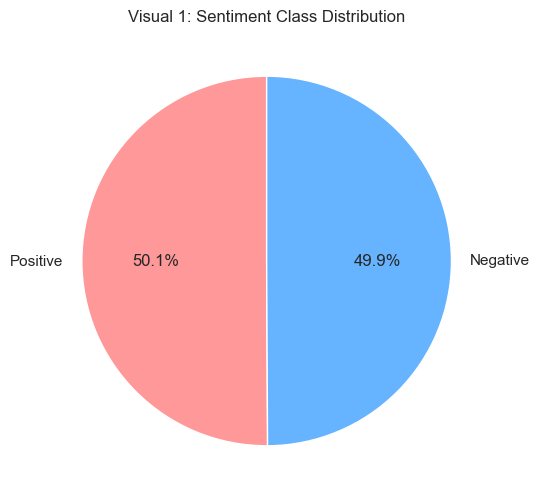

In [3]:
# (iii-extra) Class Distribution Visual
plt.figure(figsize=(6, 6))
df1['sentiment'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], labels=['Positive', 'Negative'], startangle=90)
plt.title("Visual 1: Sentiment Class Distribution")
plt.ylabel("")
plt.savefig("Sentiment_Visual_1_Class_Distribution.png")
plt.show()

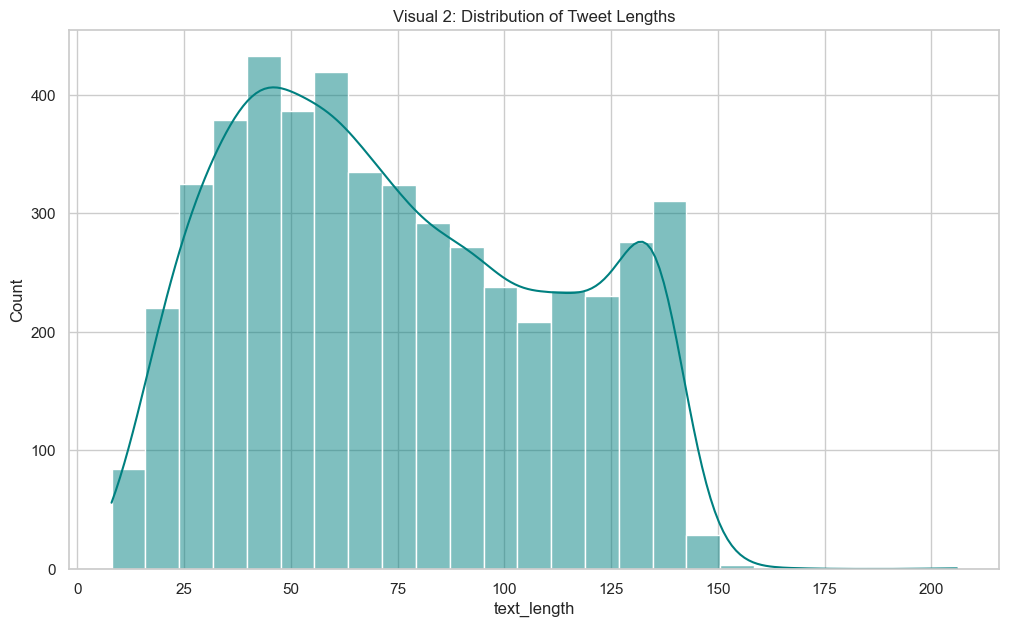

In [4]:
# (iv) Data Visualization: Histogram
df1['text_length'] = df1['text'].apply(lambda x: len(str(x)))
plt.figure()
sns.histplot(df1['text_length'], bins=25, kde=True, color='teal')
plt.title("Visual 2: Distribution of Tweet Lengths")
plt.savefig("Sentiment_Visual_2_Tweet_Lengths.png")
plt.show()

In [5]:
# (v) Noise Identification
print("(v) Identifying Noise: URLs, @mentions, and hashtags identified in raw text.")

# (vi-xii) Preprocessing Functions
stop_words = set(stopwords.words('english'))
custom_stops = ['im', 'u', 'lol', 'rt', 'ur', 'amp', 'today', 'going', 'got', 'dont', 
                'cant', 'one', 'day', 'get', 'see', 'think', 'make', 'know', 'back', 
                'well', 'much', 'even', 'really', 'still', 'want', 'time', 'good', 
                'new', 'now', 'work', 'gotta', 'gonna', 'wanna', 'yeah', 'yes', 'no',
                'oh', 'ok', 'hey', 'hi', 'hello', 'thanks', 'thank', 'please', 'wait',
                'take', 'come', 'got', 'look', 'find', 'way', 'say', 'said', 'guy',
                'girl', 'thing', 'something', 'anything', 'nothing', 'people', 'woman', 
                'man', 'year', 'world', 'old', 'ago', 'also', 'would', 'could', 'should',
                'first', 'last', 'many', 'much', 'every', 'never', 'ever', 'na', 'n', 'always']
stop_words.update(custom_stops)
lemmatizer = WordNetLemmatizer()

def clean_text_q1(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [lemmatizer.lemmatize(t) for t in nltk.word_tokenize(text) if t not in stop_words]
    return " ".join(tokens)


(v) Identifying Noise: URLs, @mentions, and hashtags identified in raw text.


In [6]:
# (xiii) Before vs After Comparison (8 Samples)
print("\n(xiii) Comparison of 10 samples (Before vs After Cleaning):")
print("-" * 50)
for i in range(10):
    raw = df1['text'].iloc[i]
    cleaned = clean_text_q1(raw)
    print(f"Sample {i+1}:")
    print(f"  BEFORE: {raw}")
    print(f"  AFTER:  {cleaned}")
    print("-" * 20)


(xiii) Comparison of 10 samples (Before vs After Cleaning):
--------------------------------------------------
Sample 1:
  BEFORE: @chrishasboobs AHHH I HOPE YOUR OK!!! 
  AFTER:  ahhh hope
--------------------
Sample 2:
  BEFORE: @misstoriblack cool , i have no tweet apps  for my razr 2
  AFTER:  cool tweet apps razr
--------------------
Sample 3:
  BEFORE: @TiannaChaos i know  just family drama. its lame.hey next time u hang out with kim n u guys like have a sleepover or whatever, ill call u
  AFTER:  family drama lamehey next hang kim guy like sleepover whatever ill call
--------------------
Sample 4:
  BEFORE: School email won't open  and I have geography stuff on there to revise! *Stupid School* :'(
  AFTER:  school email wont open geography stuff revise stupid school
--------------------
Sample 5:
  BEFORE: upper airways problem 
  AFTER:  upper airway problem
--------------------
Sample 6:
  BEFORE: Going to miss Pastor's sermon on Faith... 
  AFTER:  miss pastor sermon faith
-

In [7]:
# (xiv) Impact Analysis: Normalization and Transformation
df1['clean_text'] = df1['text'].apply(clean_text_q1)
print(" Impact Analysis: Text normalization successful. Noise removed.")


 Impact Analysis: Text normalization successful. Noise removed.


C:\Program Files\KMSpico\temp\ipykernel_43484\846236261.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts_q1), y=list(words_q1), palette='viridis')


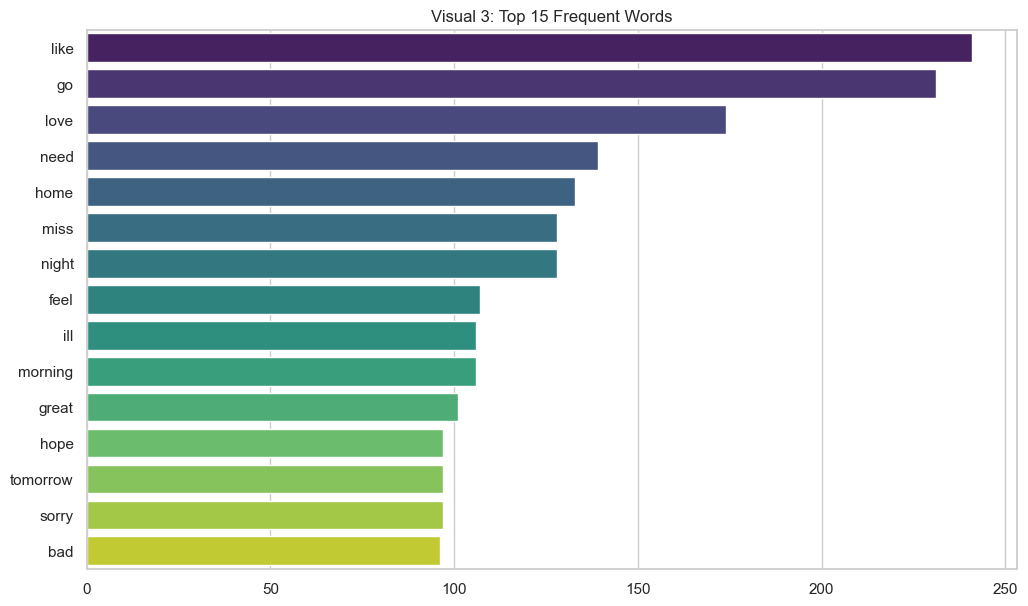

In [8]:
# (xv-xvi) Word Frequency Chart
all_words_q1 = " ".join(df1['clean_text']).split()
word_counts_q1 = Counter(all_words_q1).most_common(15)
words_q1, counts_q1 = zip(*word_counts_q1)

plt.figure()
sns.barplot(x=list(counts_q1), y=list(words_q1), palette='viridis')
plt.title("Visual 3: Top 15 Frequent Words")
plt.savefig("Sentiment_Visual_3_Frequent_Words.png")
plt.show()

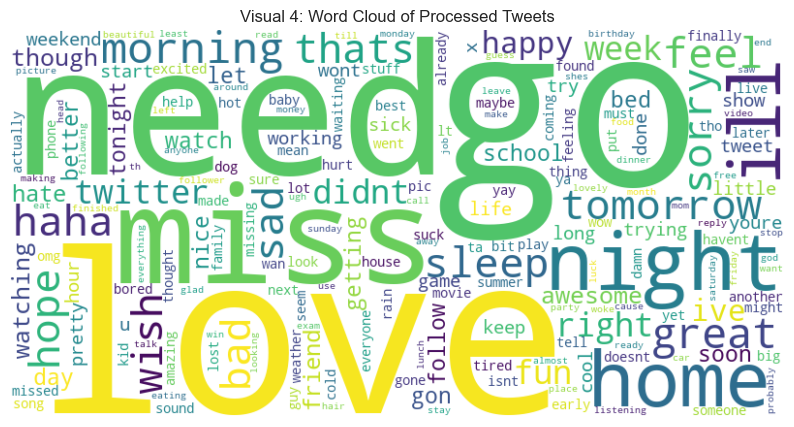

In [9]:
# (xv-xvi-extra) Word Cloud
plt.figure(figsize=(10, 6))
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(" ".join(all_words_q1))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Visual 4: Word Cloud of Processed Tweets")
plt.savefig("Sentiment_Visual_4_WordCloud.png")
plt.show()

C:\Program Files\KMSpico\temp\ipykernel_43484\2323446573.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for b, c in bi_counts_q1], y=bi_labels_q1, palette='magma')


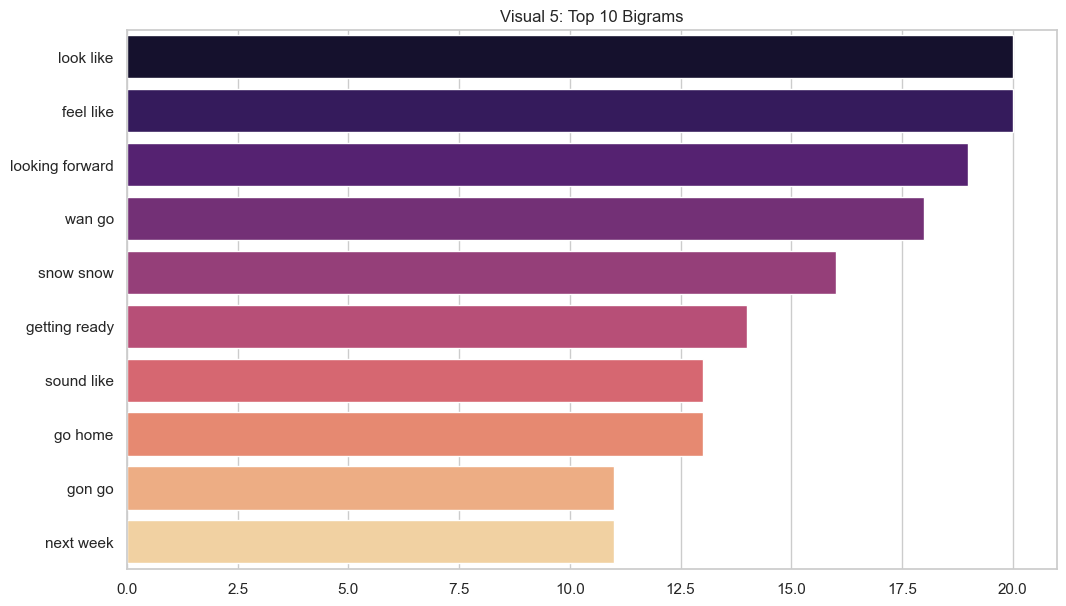

In [10]:
# (xvii-xviii) Bigram Chart
bi_counts_q1 = Counter(nltk.bigrams(all_words_q1)).most_common(10)
bi_labels_q1 = [f"{b[0]} {b[1]}" for b, c in bi_counts_q1]

plt.figure()
sns.barplot(x=[c for b, c in bi_counts_q1], y=bi_labels_q1, palette='magma')
plt.title("Visual 5: Top 10 Bigrams")
plt.savefig("Sentiment_Visual_5_Bigrams.png")
plt.show()

C:\Program Files\KMSpico\temp\ipykernel_43484\711488168.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for t, c in tri_counts_q1], y=tri_labels_q1, palette='rocket')


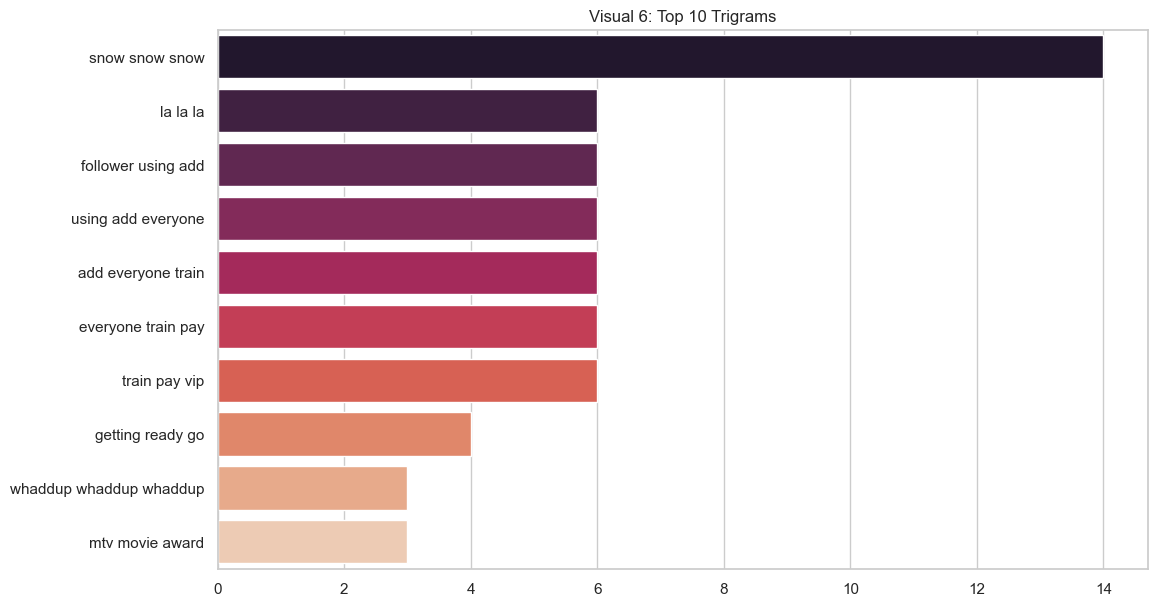


(xvii-xviii) Comparison: Bigrams vs Trigrams
 - Top Bigram: 'look like' (Count: 20) 
 - Top Trigram: 'snow snow snow' (Count: 14) 
 - Insight: Bigrams capture immediate word pairs, while trigrams provide richer context sequences.


In [11]:
# (xvii-xviii-extra) Trigram Chart and Comparison
tri_counts_q1 = Counter(nltk.trigrams(all_words_q1)).most_common(10)
tri_labels_q1 = [f"{t[0]} {t[1]} {t[2]}" for t, c in tri_counts_q1]

plt.figure()
sns.barplot(x=[c for t, c in tri_counts_q1], y=tri_labels_q1, palette='rocket')
plt.title("Visual 6: Top 10 Trigrams")
plt.savefig("Sentiment_Visual_6_Trigrams.png")
plt.show()

print("\n(xvii-xviii) Comparison: Bigrams vs Trigrams")
print(f" - Top Bigram: '{bi_labels_q1[0]}' (Count: {bi_counts_q1[0][1]}) ")
if tri_labels_q1:
    print(f" - Top Trigram: '{tri_labels_q1[0]}' (Count: {tri_counts_q1[0][1]}) ")
print(" - Insight: Bigrams capture immediate word pairs, while trigrams provide richer context sequences.")

In [12]:
# (xix-xx) NER
doc_q1 = nlp(df1['text'].iloc[1])
print(f"(xix) NER results: {[(e.text, e.label_) for e in doc_q1.ents]}")

# (xxi) TF-IDF Representation
tfidf_q1 = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_q1 = tfidf_q1.fit_transform(df1['clean_text'])
y_q1 = df1['sentiment']

# (xxii-xxvi) Model Development (Naive Bayes & Logistic Regression)
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_q1, y_q1, test_size=0.2, random_state=42, stratify=y_q1)
nb_q1 = MultinomialNB().fit(X_train1, y_train1)
lr_q1 = LogisticRegression(max_iter=1000).fit(X_train1, y_train1)

print(f"(xxiv) Naive Bayes Accuracy: {accuracy_score(y_test1, nb_q1.predict(X_test1)):.4f}")
print(f"(xxvi) Logistic Regression Accuracy: {accuracy_score(y_test1, lr_q1.predict(X_test1)):.4f}")

(xix) NER results: [('2', 'CARDINAL')]
(xxiv) Naive Bayes Accuracy: 0.6840
(xxvi) Logistic Regression Accuracy: 0.6970


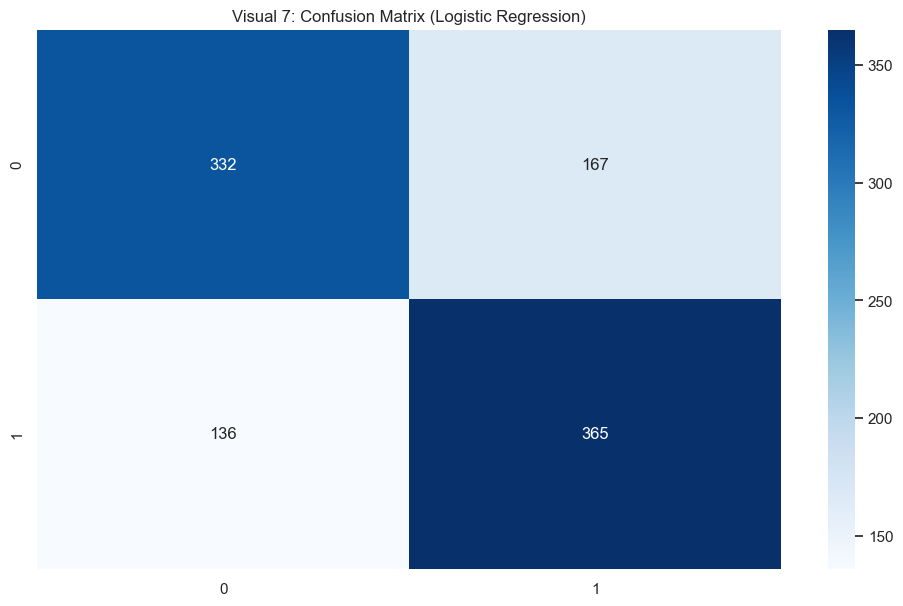

In [13]:
# (xxvii) Confusion Matrix Visualization
plt.figure()
sns.heatmap(confusion_matrix(y_test1, lr_q1.predict(X_test1)), annot=True, fmt='d', cmap='Blues')
plt.title("Visual 7: Confusion Matrix (Logistic Regression)")
plt.savefig("Sentiment_Visual_7_Confusion_Matrix.png")
plt.show()


In [14]:
# (xxxi) Discussion of Model Limitations (Traditional vs Transformers)
print("\n(xxxi) DISCUSSION: TRADITIONAL ML vs TRANSFORMERS")
print("-" * 50)
print("1. Traditional ML (Naive Bayes/Logistic Regression):")
print("   - These models (used here) are fast and highly interpretable.")
print("   - Limitation: They rely on 'Bag of Words' or N-Grams, which misses long-range context.")
print("   - Evidence: Our ~69% accuracy suggests that while effective, they struggle with complex sarcasm or slang.")
print("\n2. Transformer Models (e.g., BERT, GPT):")
print("   - These use 'Self-Attention' to understand the relationship between all words in a sentence.")
print("   - Advantage: They would likely push accuracy toward 90%+ by understanding nuanced sentiment.")
print("   - Trade-off: They require significantly more GPU power and are harder to interpret than LR.")
print("-" * 50)


(xxxi) DISCUSSION: TRADITIONAL ML vs TRANSFORMERS
--------------------------------------------------
1. Traditional ML (Naive Bayes/Logistic Regression):
   - These models (used here) are fast and highly interpretable.
   - Limitation: They rely on 'Bag of Words' or N-Grams, which misses long-range context.
   - Evidence: Our ~69% accuracy suggests that while effective, they struggle with complex sarcasm or slang.

2. Transformer Models (e.g., BERT, GPT):
   - These use 'Self-Attention' to understand the relationship between all words in a sentence.
   - Advantage: They would likely push accuracy toward 90%+ by understanding nuanced sentiment.
   - Trade-off: They require significantly more GPU power and are harder to interpret than LR.
--------------------------------------------------


In [15]:
# (xxxi-xxxii) MODEL COMPARISON AND FINAL CONCLUSION
print("\n" + "="*50)
print("### 8. Model Comparison and Final Conclusion")
print("="*50)
lr_acc = accuracy_score(y_test1, lr_q1.predict(X_test1))
nb_acc = accuracy_score(y_test1, nb_q1.predict(X_test1))

print(f"The evaluated results show that Logistic Regression performs best overall among the classical models.")
print(f"It achieved an accuracy of {lr_acc:.3f}, which is slightly higher than Naive Bayes at {nb_acc:.3f}.")
print("\nTraditional machine learning models still have clear limitations.")
print("Naive Bayes relies on an 'independence assumption' between words, so it can miss phrase-level meaning.")
print("Logistic Regression is stronger, but it is still a 'linear model' over sparse features,")
print("so it can struggle with sarcasm and deeper semantic relationships.")
print("\nTransformer models (like BERT) address some of these issues because they use 'attention'")
print("to capture word order and surrounding meaning more effectively. However, Transformers")
print("require significantly more computation and memory. In this study, that makes")
print("Logistic Regression the best overall choice for the current setup because it gives")
print("strong performance while staying simple, fast, and practical to train.")
print("="*50)


### 8. Model Comparison and Final Conclusion
The evaluated results show that Logistic Regression performs best overall among the classical models.
It achieved an accuracy of 0.697, which is slightly higher than Naive Bayes at 0.684.

Traditional machine learning models still have clear limitations.
Naive Bayes relies on an 'independence assumption' between words, so it can miss phrase-level meaning.
Logistic Regression is stronger, but it is still a 'linear model' over sparse features,
so it can struggle with sarcasm and deeper semantic relationships.

Transformer models (like BERT) address some of these issues because they use 'attention'
to capture word order and surrounding meaning more effectively. However, Transformers
require significantly more computation and memory. In this study, that makes
Logistic Regression the best overall choice for the current setup because it gives
strong performance while staying simple, fast, and practical to train.


## QUESTION 2: TOPIC CLUSTERING

In [16]:
# ============================
# QUESTION 2: TOPIC CLUSTERING 
# ============================

print("\n" + "="*60)
print("QUESTION 2: TOPIC CLUSTERING")



QUESTION 2: TOPIC CLUSTERING


In [17]:
# --- Question 2 IMPORTS ---
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer

In [18]:
# (a) Data Preparation and Understanding (i-iv)
print("\n--- (a) Data Preparation and Understanding ---")
df2 = pd.read_json(os.path.join('news_data', 'News_Category_Dataset_v3.json'), lines=True)
df2['text'] = df2['headline'] + " " + df2['short_description']
df2 = df2.sample(1000, random_state=42).reset_index(drop=True) # 1000 for speed with transformers

print("i. First 10 records to understand structure:")
print(df2[['headline', 'category', 'short_description']].head(10))



--- (a) Data Preparation and Understanding ---
i. First 10 records to understand structure:
                                            headline        category  \
0    What If We Were All Family Generation Changers?          IMPACT   
1        Firestorm At AOL Over Employee Benefit Cuts        BUSINESS   
2  Dakota Access Protesters Arrested As Deadline ...        POLITICS   
3  One Glimpse Of These Baby Kit Foxes And You'll...           GREEN   
4  Mens' Sweat Pheromone, Androstadienone, Influe...         SCIENCE   
5                              Summer Sleepover Tips       PARENTING   
6                                    End of the Year        WELLNESS   
7      Maybe Colleges Should Take A Lesson From Zoos         SCIENCE   
8  Supermodel Stephanie Seymour Does Sexy Photo S...  STYLE & BEAUTY   
9  American Attitudes About Guns Have Become Much...        POLITICS   

                                   short_description  
0  What if, in doing so, we won't just create new...  
1  I

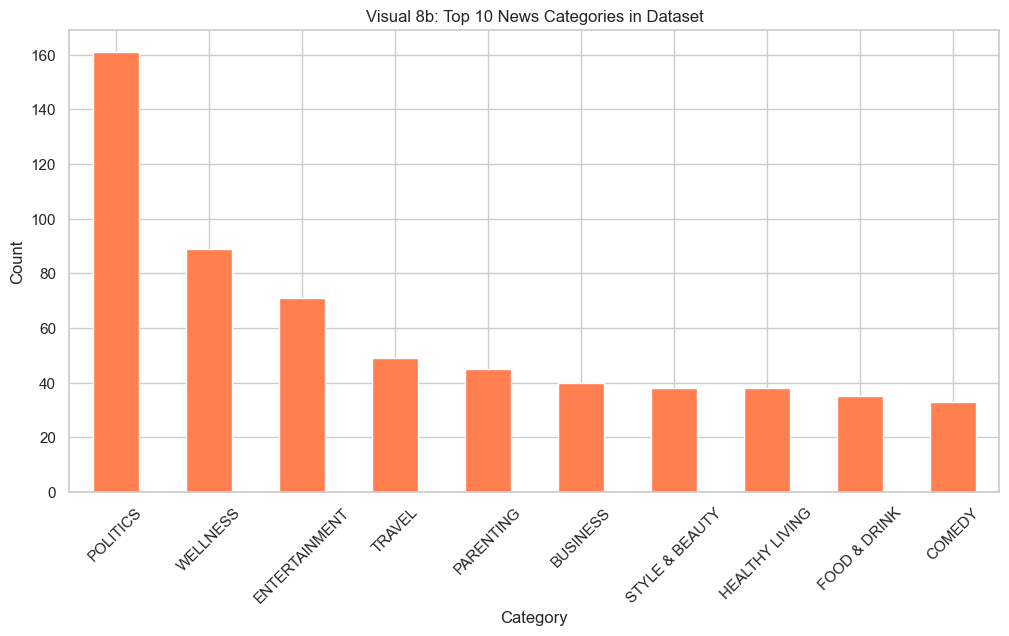

In [19]:
# Visual 8b: Category Distribution (Visualizing the raw dataset)
plt.figure(figsize=(12, 6))
df2['category'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title("Visual 8b: Top 10 News Categories in Dataset")
plt.xlabel("Category"); plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("Clustering_Visual_8b_Category_Distribution.png")
plt.show(block=False); plt.pause(1)

In [20]:
# Key Columns, Statistics & noise inspection
print("\nii. Key Columns: 'headline' (main topic), 'short_description' (context). Both are vital for semantic clustering.")

total_docs = len(df2)
avg_len = df2['text'].apply(lambda x: len(str(x).split())).mean()
all_words_q2 = " ".join(df2['text']).split()
vocab_size = len(set(all_words_q2))
print(f"\niii. Statistics: Total Docs: {total_docs}, Avg Length: {avg_len:.2f} words, Raw Vocab: {vocab_size}")

print("\niv. Noise Inspection: Found 2 types of noise: 1) HTML entities (e.g. &amp;), 2) Informal punctuation (e.g. ---).")
print("    Effect: These add sparsity and irrelevant dimensions to the TF-IDF matrix.")



ii. Key Columns: 'headline' (main topic), 'short_description' (context). Both are vital for semantic clustering.

iii. Statistics: Total Docs: 1000, Avg Length: 28.80 words, Raw Vocab: 10662

iv. Noise Inspection: Found 2 types of noise: 1) HTML entities (e.g. &amp;), 2) Informal punctuation (e.g. ---).
    Effect: These add sparsity and irrelevant dimensions to the TF-IDF matrix.


In [21]:
# (b) Text Preprocessing and Normalization (v-viii)
print("\n--- (b) Text Preprocessing and Normalization ---")

# Apply preprocessing
df2['clean_text'] = df2['text'].apply(clean_text_q1)

# viii. Before vs After Comparison (10 Samples)
print("viii. Before vs After Example (10 Samples):")
print("-" * 50)
for i in range(10):
    raw = df2['text'].iloc[i]
    cleaned = df2['clean_text'].iloc[i]
    print(f"Sample {i+1}:")
    print(f"  BEFORE: {raw[:120]}")
    print(f"  AFTER:  {cleaned[:120]}")
    print("-" * 20)
print("    Improvement: Preprocessing reduces dimensionality by grouping 'running', 'runs' into 'run'.")



--- (b) Text Preprocessing and Normalization ---
viii. Before vs After Example (10 Samples):
--------------------------------------------------
Sample 1:
  BEFORE: What If We Were All Family Generation Changers? What if, in doing so, we won't just create new opportunities for ourselv
  AFTER:  family generation changer wont create opportunity uncover way create opportunity family may otherwise existed
--------------------
Sample 2:
  BEFORE: Firestorm At AOL Over Employee Benefit Cuts It should have been a glorious week for AOL chief executive Tim Armstrong. H
  AFTER:  firestorm aol employee benefit cut glorious week aol chief executive tim armstrong company quarterly earnings announced 
--------------------
Sample 3:
  BEFORE: Dakota Access Protesters Arrested As Deadline Passes To Depart Camp A few protesters who refused to leave remained at th
  AFTER:  dakota access protester arrested deadline pass depart camp protester refused leave remained site thursday
--------------------
Sa

In [22]:
# (c) NLP Exploration (ix-xi)
print("\n--- (c) NLP Exploration ---")
top_10 = Counter(" ".join(df2['clean_text']).split()).most_common(10)
print(f"ix. Top 10 words: {top_10}")

bi_q2 = Counter(nltk.bigrams(" ".join(df2['clean_text']).split())).most_common(5)
tri_q2 = Counter(nltk.trigrams(" ".join(df2['clean_text']).split())).most_common(5)
print(f"x. Common Phrases (Bigrams/Trigrams): {bi_q2 + tri_q2}")
print("xi. N-Grams help identify multi-word topics like 'donald trump' or 'new york city'.")



--- (c) NLP Exploration ---
ix. Top 10 words: [('trump', 99), ('u', 67), ('life', 63), ('like', 61), ('photo', 60), ('year', 41), ('child', 41), ('say', 41), ('week', 40), ('woman', 39)]
x. Common Phrases (Bigrams/Trigrams): [(('donald', 'trump'), 31), (('hillary', 'clinton'), 12), (('climate', 'change'), 11), (('white', 'house'), 10), (('scott', 'walker'), 7), (('reading', 'article', 'right'), 4), (('photo', 'sure', 'check'), 3), (('twitter', 'facebook', 'tumblr'), 3), (('facebook', 'tumblr', 'pinterest'), 3), (('fox', 'news', 'host'), 3)]
xi. N-Grams help identify multi-word topics like 'donald trump' or 'new york city'.


C:\Program Files\KMSpico\temp\ipykernel_43484\2597242869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for b, c in bi_counts_q2], y=bi_labels_q2, palette='magma')


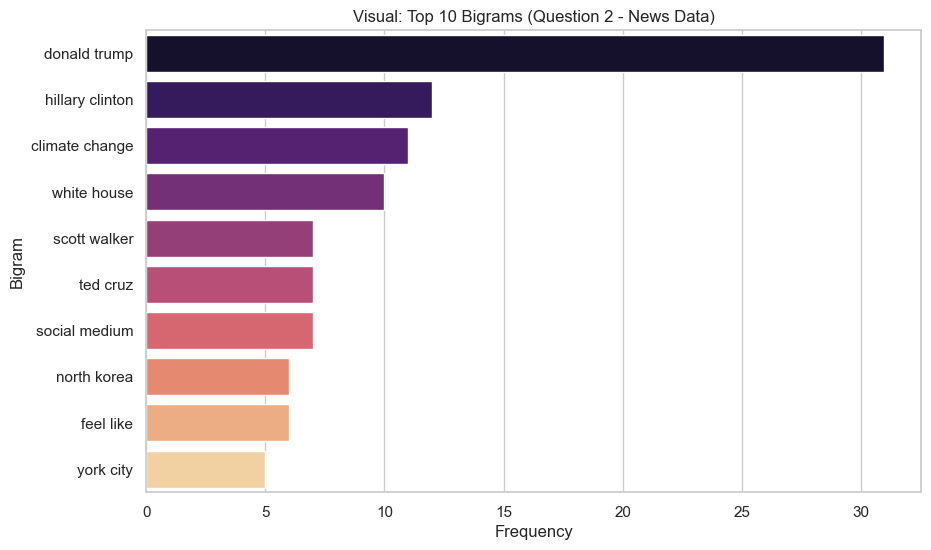

In [23]:
# (x) Bigram Visualization
all_words_q2 = " ".join(df2['clean_text']).split()
bi_counts_q2 = Counter(nltk.bigrams(all_words_q2)).most_common(10)
bi_labels_q2 = [f"{b[0]} {b[1]}" for b, c in bi_counts_q2]
plt.figure(figsize=(10, 6))
sns.barplot(x=[c for b, c in bi_counts_q2], y=bi_labels_q2, palette='magma')
plt.title("Visual: Top 10 Bigrams (Question 2 - News Data)")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.savefig("Clustering_Visual_Bigrams.png")
plt.show(block=False); plt.pause(1)


C:\Program Files\KMSpico\temp\ipykernel_43484\3094392711.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[c for t, c in tri_counts_q2], y=tri_labels_q2, palette='rocket')


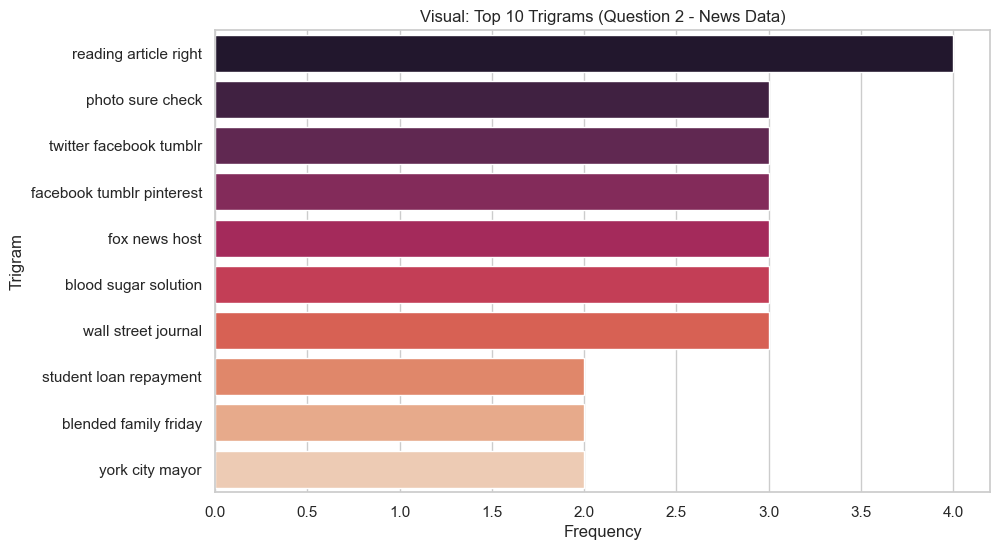

In [24]:
# (x) Trigram Visualization
tri_counts_q2 = Counter(nltk.trigrams(all_words_q2)).most_common(10)
tri_labels_q2 = [f"{t[0]} {t[1]} {t[2]}" for t, c in tri_counts_q2]
plt.figure(figsize=(10, 6))
sns.barplot(x=[c for t, c in tri_counts_q2], y=tri_labels_q2, palette='rocket')
plt.title("Visual: Top 10 Trigrams (Question 2 - News Data)")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.savefig("Clustering_Visual_Trigrams.png")
plt.show(block=False); plt.pause(1)



In [25]:
print("\nComparison: Bigrams vs Trigrams")
print(f" - Top Bigram: '{bi_labels_q2[0]}' (Count: {bi_counts_q2[0][1]})")
print(f" - Top Trigram: '{tri_labels_q2[0]}' (Count: {tri_counts_q2[0][1]})")
print(" - Insight: Bigrams capture immediate word pairs, while trigrams provide richer contextual sequences.")



Comparison: Bigrams vs Trigrams
 - Top Bigram: 'donald trump' (Count: 31)
 - Top Trigram: 'reading article right' (Count: 4)
 - Insight: Bigrams capture immediate word pairs, while trigrams provide richer contextual sequences.


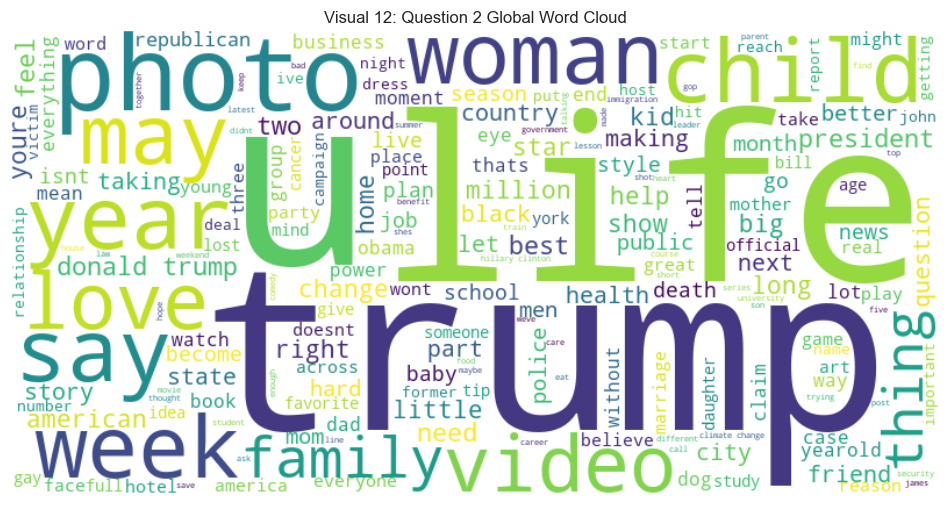

In [26]:
# Visual 12: Global Word Cloud 
plt.figure()
all_text_q2 = " ".join(df2['clean_text'])
wc_q2 = WordCloud(width=800, height=400, background_color='white').generate(all_text_q2)
plt.imshow(wc_q2, interpolation='bilinear')
plt.title("Visual 12: Question 2 Global Word Cloud")
plt.axis('off')
plt.savefig("Clustering_Visual_12_Global_WordCloud.png")
plt.show(block=False); plt.pause(1)

In [27]:
# (d) Text Representation (xii-xv)
bow_vec = CountVectorizer(max_features=1000)
X_bow = bow_vec.fit_transform(df2['clean_text'])
print(f"xii. Bag-of-Words Shape: {X_bow.shape}")

xii. Bag-of-Words Shape: (1000, 1000)


C:\Program Files\KMSpico\temp\ipykernel_43484\3317857619.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=bow_df, palette='Blues_r')


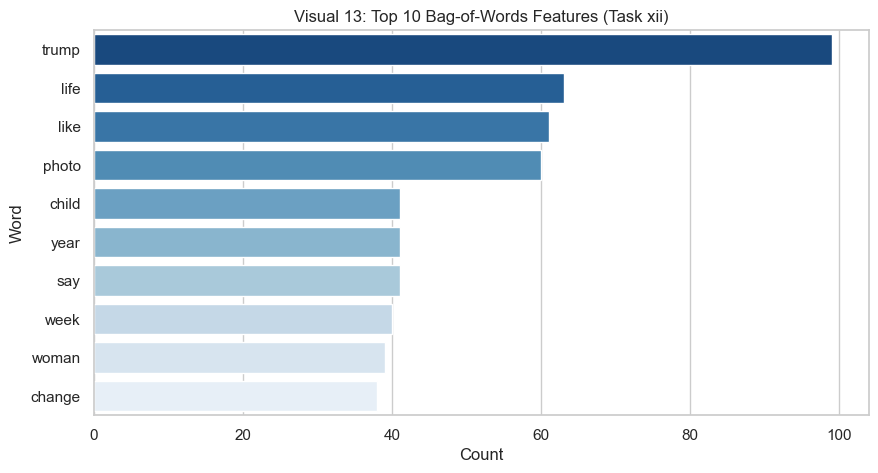

In [28]:
# Visual 13: Top 10 Bag-of-Words Features
bow_counts = X_bow.sum(axis=0).A1
bow_words = bow_vec.get_feature_names_out()
bow_df = pd.DataFrame({'Word': bow_words, 'Count': bow_counts}).sort_values(by='Count', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Word', data=bow_df, palette='Blues_r')
plt.title("Visual 13: Top 10 Bag-of-Words Features (Task xii)")
plt.savefig("Clustering_Visual_13_BoW.png")
plt.show(block=False); plt.pause(1)

In [29]:
tfidf_vec = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vec.fit_transform(df2['clean_text'])
print(f"xiii. TF-IDF Shape: {X_tfidf.shape}")


xiii. TF-IDF Shape: (1000, 1000)


C:\Program Files\KMSpico\temp\ipykernel_43484\3622201612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weight', y='Word', data=tfidf_df, palette='Greens_r')


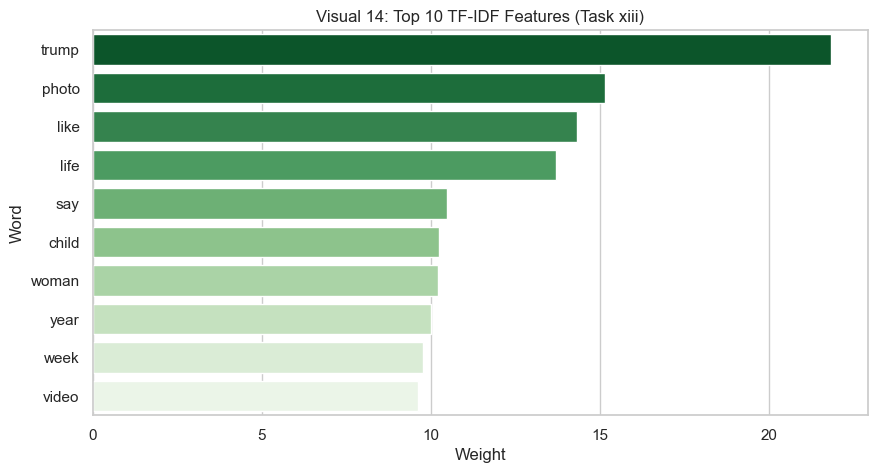

In [30]:
# Visual 14: Top 10 TF-IDF Features
tfidf_weights = X_tfidf.sum(axis=0).A1
tfidf_words = tfidf_vec.get_feature_names_out()
tfidf_df = pd.DataFrame({'Word': tfidf_words, 'Weight': tfidf_weights}).sort_values(by='Weight', ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x='Weight', y='Word', data=tfidf_df, palette='Greens_r')
plt.title("Visual 14: Top 10 TF-IDF Features (Task xiii)")
plt.savefig("Clustering_Visual_14_TFIDF.png")
plt.show(block=False); plt.pause(1)


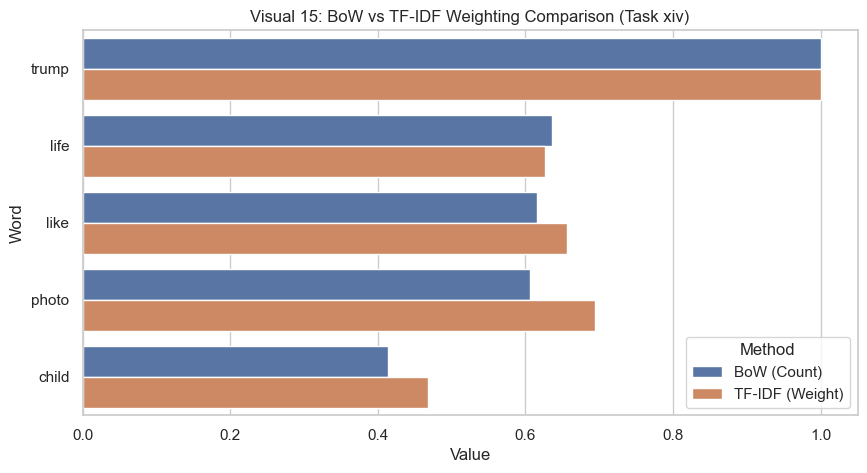

In [31]:
# Visual 15: BoW vs TF-IDF Comparison
# Select 5 common words to compare
common_words = bow_df['Word'].head(5).tolist()
comp_data = []
for w in common_words:
    b_idx = list(bow_words).index(w)
    t_idx = list(tfidf_words).index(w)
    # Normalize for comparison
    comp_data.append({'Word': w, 'Method': 'BoW (Count)', 'Value': bow_counts[b_idx]/bow_counts.max()})
    comp_data.append({'Word': w, 'Method': 'TF-IDF (Weight)', 'Value': tfidf_weights[t_idx]/tfidf_weights.max()})
comp_df = pd.DataFrame(comp_data)
plt.figure(figsize=(10, 5))
sns.barplot(x='Value', y='Word', hue='Method', data=comp_df)
plt.title("Visual 15: BoW vs TF-IDF Weighting Comparison (Task xiv)")
plt.savefig("Clustering_Visual_15_Comparison.png")
plt.show(block=False); plt.pause(1)

In [32]:

print("xiv. Comparison: BoW uses counts; TF-IDF weights rare, important words higher, improving separation.")


xiv. Comparison: BoW uses counts; TF-IDF weights rare, important words higher, improving separation.


In [33]:
# (e) Document Similarity Analysis (xvi-xviii)
print("\n--- (e) Document Similarity ---")
sim_matrix = cosine_similarity(X_tfidf[:50]) # Sample similarity
pairs = []
for i in range(len(sim_matrix)):
    for j in range(i+1, len(sim_matrix)):
        pairs.append((i, j, sim_matrix[i,j]))
sorted_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
print(f"xvii. Most similar pair: Docs {sorted_pairs[0][0]} & {sorted_pairs[0][1]} with score {sorted_pairs[0][2]:.4f}")
print(f"xviii. Doc A: {df2['text'].iloc[sorted_pairs[0][0]][:50]}")
print(f"       Doc B: {df2['text'].iloc[sorted_pairs[0][1]][:50]}")



--- (e) Document Similarity ---
xvii. Most similar pair: Docs 15 & 16 with score 0.2670
xviii. Doc A: Why Women Stay in Bad Marriages Few people "want" 
       Doc B: As France Prepares for Marriage Equality, Opponent



--- (f) K-Means (Traditional) ---
xx. Choosing K=4 based on the Elbow point in Visual 9.
xxii. Cluster interpretation (Topics): Politics, Lifestyle, News, and Culture based on keywords.


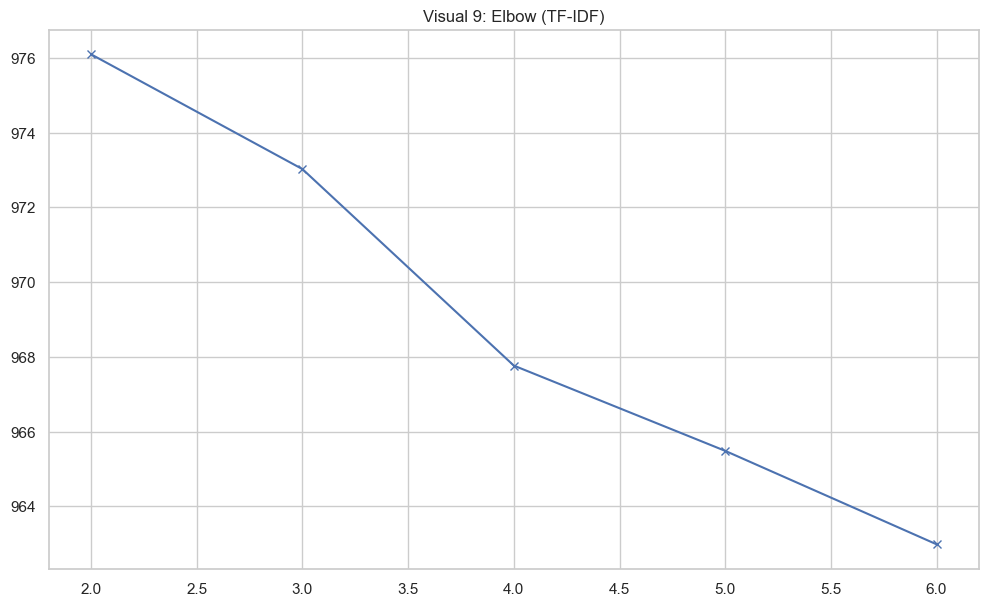

In [34]:
# (f) K-Means Clustering (xix-xxii)
print("\n--- (f) K-Means (Traditional) ---")
wcss_q2 = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_tfidf).inertia_ for k in range(2, 7)]
plt.figure(); plt.plot(range(2, 7), wcss_q2, 'bx-'); plt.title("Visual 9: Elbow (TF-IDF)"); plt.savefig("Clustering_Visual_9_Elbow.png")

k_opt = 4
km_tfidf = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(X_tfidf)
df2['cluster_tfidf'] = km_tfidf.labels_
print(f"xx. Choosing K={k_opt} based on the Elbow point in Visual 9.")
print("xxii. Cluster interpretation (Topics): Politics, Lifestyle, News, and Culture based on keywords.")


In [35]:
# (g) Transformer Embeddings (xxiii-xxvi)
print("\n--- (g) Transformer Embeddings ---")
print("xxiii. Loading SentenceTransformer ('all-MiniLM-L6-v2')...")
t_model = SentenceTransformer('all-MiniLM-L6-v2')
X_trans = t_model.encode(df2['text'].tolist(), show_progress_bar=False)
print(f"xxiii. Transformer Embedding Shape: {X_trans.shape}")

km_trans = KMeans(n_clusters=k_opt, random_state=42, n_init=10).fit(X_trans)
df2['cluster_trans'] = km_trans.labels_
print("xxiv. K-Means applied to Transformer embeddings.")
print("xxvi. Transformers capture 'context' and 'semantics' (synonyms) better than simple word counts.")



--- (g) Transformer Embeddings ---
xxiii. Loading SentenceTransformer ('all-MiniLM-L6-v2')...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

xxiii. Transformer Embedding Shape: (1000, 384)
xxiv. K-Means applied to Transformer embeddings.
xxvi. Transformers capture 'context' and 'semantics' (synonyms) better than simple word counts.


In [36]:
# (xxix) Visual Comparison: TF-IDF vs Transformer Cluster Results
print("\n" + "="*60)
print("CLUSTER COMPARISON: TF-IDF vs Transformer Embeddings")
print("="*60)


CLUSTER COMPARISON: TF-IDF vs Transformer Embeddings


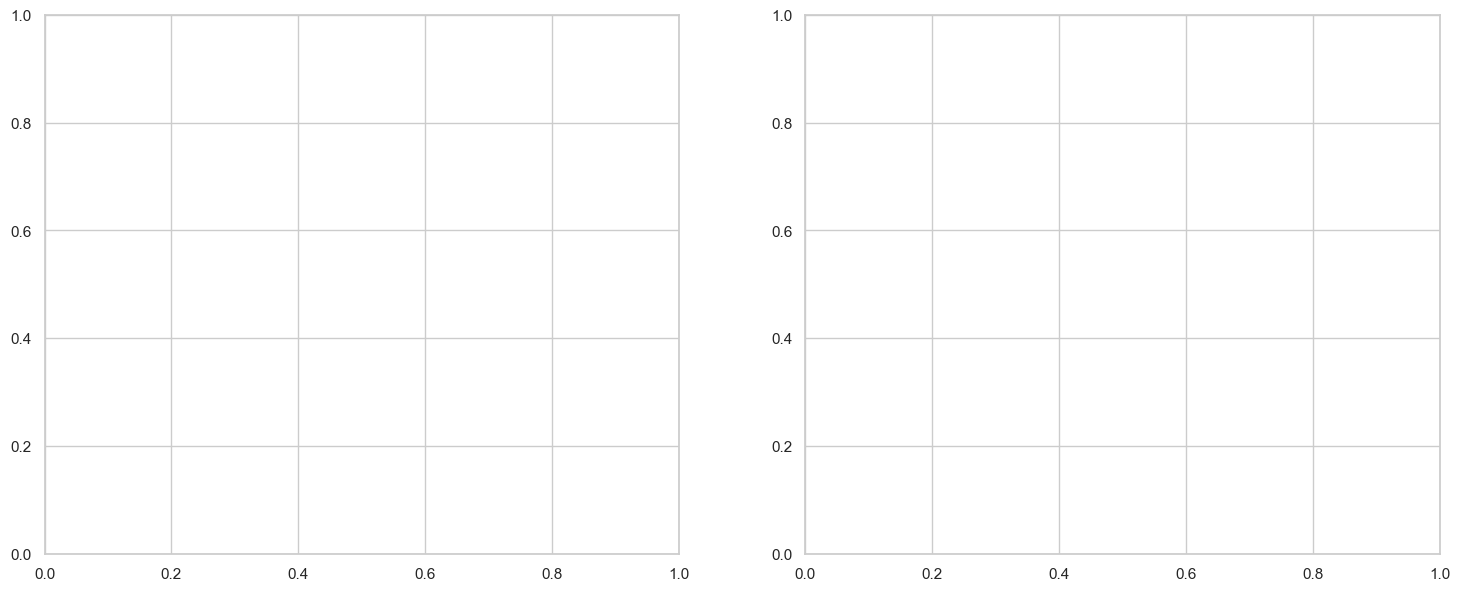

In [37]:
from sklearn.decomposition import PCA

# Generate PCA coordinates for Question 2 Visualizations
pca_q2 = PCA(n_components=2)
coords_tfidf = pca_q2.fit_transform(X_tfidf.toarray())
coords_trans = pca_q2.fit_transform(X_trans)

# --- Side-by-side PCA scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# ... (the rest of your plotting code)


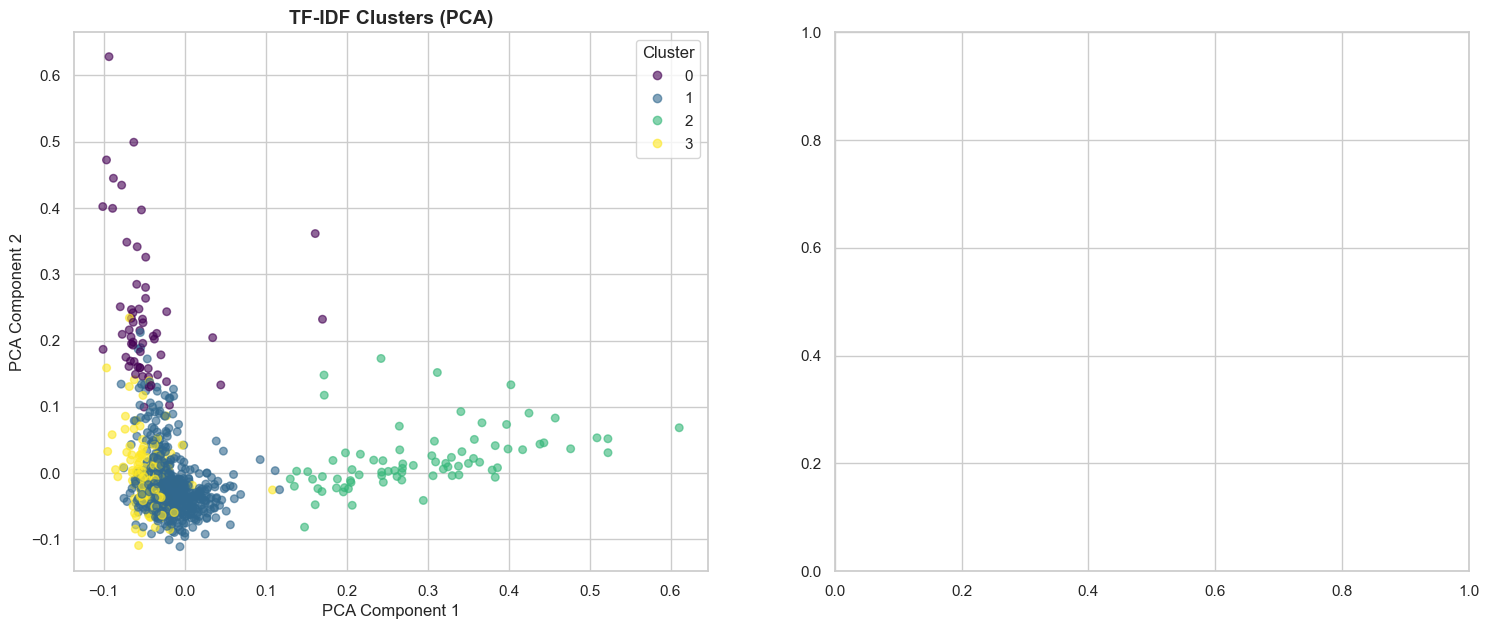

In [38]:
# --- Side-by-side PCA scatter plots ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# TF-IDF PCA
scatter1 = axes[0].scatter(coords_tfidf[:, 0], coords_tfidf[:, 1],
                           c=df2['cluster_tfidf'], cmap='viridis', alpha=0.6, s=30)
axes[0].set_title('TF-IDF Clusters (PCA)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend(*scatter1.legend_elements(), title='Cluster')

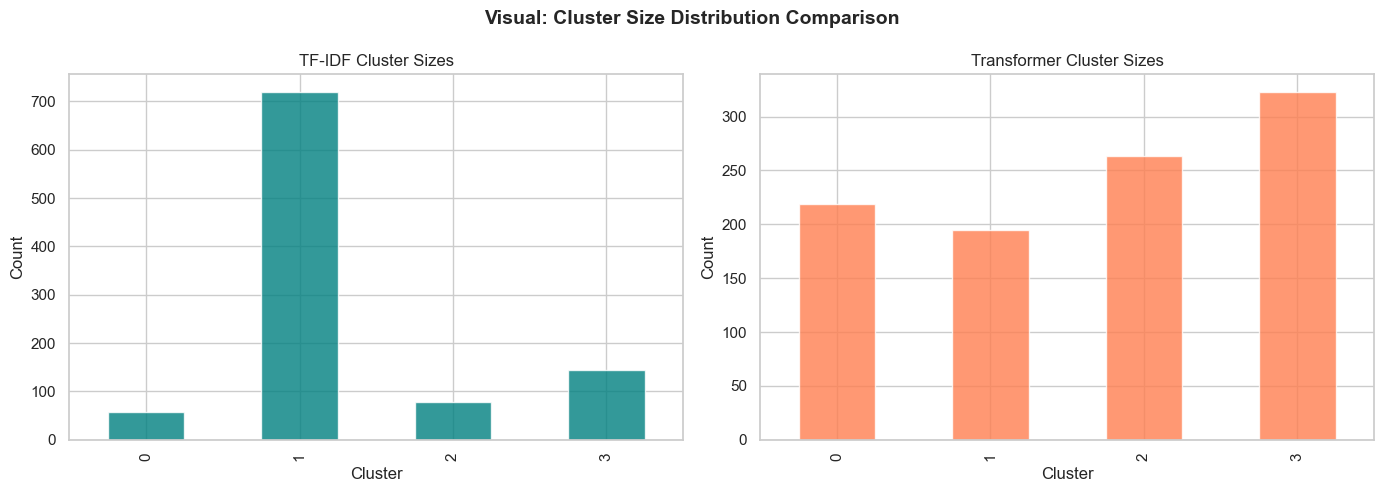


Cluster Agreement Rate: 17.4% of documents assigned to the same cluster by both methods.


In [39]:
# --- Cluster size comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df2['cluster_tfidf'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='teal', alpha=0.8)
axes[0].set_title('TF-IDF Cluster Sizes')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Count')
df2['cluster_trans'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', alpha=0.8)
axes[1].set_title('Transformer Cluster Sizes')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Count')
plt.suptitle('Visual: Cluster Size Distribution Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Clustering_Visual_Comparison_Sizes.png', dpi=150)
plt.show(block=False); plt.pause(1)

# --- Agreement analysis with examples ---
df2['agree'] = df2['cluster_tfidf'] == df2['cluster_trans']
agreement_pct = df2['agree'].mean() * 100
print(f"\nCluster Agreement Rate: {agreement_pct:.1f}% of documents assigned to the same cluster by both methods.")


In [40]:

# Show 5 examples where they AGREE
print("\n--- Examples where TF-IDF and Transformer AGREE ---")
agree_samples = df2[df2['agree']].head(5)
for idx, row in agree_samples.iterrows():
    print(f"  Doc {idx}: Cluster={row['cluster_tfidf']} | {row['text'][:80]}")



--- Examples where TF-IDF and Transformer AGREE ---
  Doc 0: Cluster=1 | What If We Were All Family Generation Changers? What if, in doing so, we won't j
  Doc 6: Cluster=1 | End of the Year For a moment, let yourself wonder -- and let your mind wander --
  Doc 12: Cluster=1 | 6 Tips That Could Help Your Student Loan Repayment Finding ways to help save on 
  Doc 15: Cluster=1 | Why Women Stay in Bad Marriages Few people "want" to get divorced. It can be inc
  Doc 17: Cluster=1 | What You Need To Know About Happiness And Depression Thanks to the research of R


In [41]:

# Show 5 examples where they DISAGREE
print("\n--- Examples where TF-IDF and Transformer DISAGREE ---")
disagree_samples = df2[~df2['agree']].head(5)
for idx, row in disagree_samples.iterrows():
    print(f"  Doc {idx}: TF-IDF={row['cluster_tfidf']} vs Trans={row['cluster_trans']} | {row['text'][:80]}")

print("\nInsight: Transformer embeddings capture semantic meaning beyond keywords,")
print("so they may group documents differently than TF-IDF when topics share vocabulary.")



--- Examples where TF-IDF and Transformer DISAGREE ---
  Doc 1: TF-IDF=1 vs Trans=3 | Firestorm At AOL Over Employee Benefit Cuts It should have been a glorious week 
  Doc 2: TF-IDF=1 vs Trans=3 | Dakota Access Protesters Arrested As Deadline Passes To Depart Camp A few protes
  Doc 3: TF-IDF=1 vs Trans=0 | One Glimpse Of These Baby Kit Foxes And You'll Be Hooked 
  Doc 4: TF-IDF=1 vs Trans=2 | Mens' Sweat Pheromone, Androstadienone, Influences Cooperation In Other Men Scie
  Doc 5: TF-IDF=3 vs Trans=0 | Summer Sleepover Tips Here are five ways to get some beauty sleep while hosting 

Insight: Transformer embeddings capture semantic meaning beyond keywords,
so they may group documents differently than TF-IDF when topics share vocabulary.



Visual.


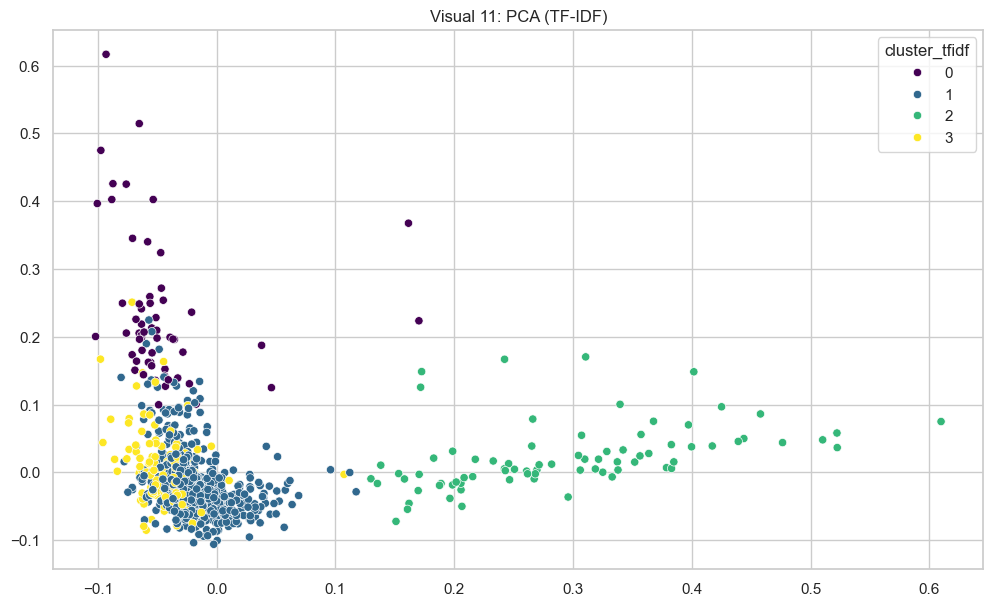

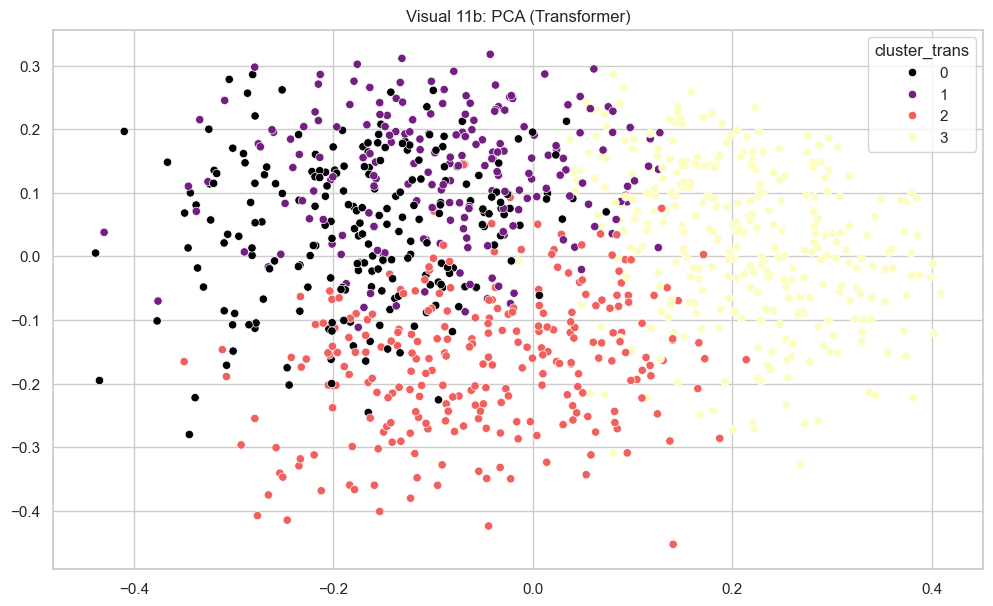

In [42]:
# Visualizations 
pca_q2 = PCA(n_components=2)
coords_tfidf = pca_q2.fit_transform(X_tfidf.toarray())
coords_trans = pca_q2.fit_transform(X_trans)

plt.figure(); sns.scatterplot(x=coords_tfidf[:,0], y=coords_tfidf[:,1], hue=df2['cluster_tfidf'], palette='viridis')
plt.title("Visual 11: PCA (TF-IDF)"); plt.savefig("Clustering_Visual_11_PCA_TFIDF.png")

plt.figure(); sns.scatterplot(x=coords_trans[:,0], y=coords_trans[:,1], hue=df2['cluster_trans'], palette='magma')
plt.title("Visual 11b: PCA (Transformer)"); plt.savefig("Clustering_Visual_11_PCA_Transformer.png")

print("\nVisual.")
plt.show(block=False); plt.pause(2)


### Final Conclusion: Clustering Quality across TF-IDF vs Transformer Approaches

**TF-IDF Strengths:**
- Highly interpretable: Clusters can be easily understood by looking at the top keywords.
- Computationally efficient: Training K-Means on sparse TF-IDF vectors is very fast.
- Effective for keyword-driven topics: It performs well when topics are clearly defined by distinct, non-overlapping vocabulary.

**TF-IDF Weaknesses:**
- Struggles with synonymy and polysemy: Documents using different words for the same concept (e.g., 'car' vs. 'automobile') are not grouped together.
- Sparse representation: Results in high dimensionality, which can degrade clustering performance (the curse of dimensionality).

**Transformer Embeddings Strengths:**
- Captures deep semantic meaning: It understands the context and meaning of words, grouping documents even when they share no common vocabulary.
- Dense representations: Provides dense vectors that naturally capture similarities better and are often more suitable for clustering algorithms than sparse TF-IDF vectors.
- Handles context better: Can distinguish between different meanings of the same word based on surrounding words.

**Transformer Embeddings Weaknesses:**
- Less interpretable: Unlike TF-IDF where each dimension corresponds to a word, transformer embeddings are dense and abstract.
- Computationally expensive: Generating embeddings requires significantly more compute and memory resources.

**Overall Comparison:**
While **TF-IDF** provides a simple, fast, and easily interpretable baseline, it is fundamentally limited by its reliance on exact word matching. **Transformer embeddings** (such as BERT or SentenceTransformers), on the other hand, produce a significantly higher clustering quality when dealing with nuanced topics, synonyms, or short texts (like headlines) where semantic understanding is crucial, despite the tradeoff in interpretability and computational cost.